# This section of the script generates a pointcloud h5 file from CT images

In [1]:
import os
import cv2
import numpy as np
from PIL import Image

import pandas as pd
import h5py
from joblib import Parallel, delayed


# Voxel size (microns)
XY_RESOLUTION_UM = 21.0
Z_RESOLUTION_UM  = 21.0

# Positive coordinate offsets (microns) to avoid 0
XY_ORIGIN_UM = 10.0
Z_ORIGIN_UM  = 10.0

# Coordinate convention
FLIP_Y_TO_BOTTOM_LEFT = True

# Z behavior
RESET_Z_PER_CHUNK = True


# Extraction
EXTRACT_MODE = "voids"   # "voids" or "material"

# Sampling
NUM_SAMPLES_PER_SLICE = 50000

# Chunking
CHUNK_SIZE = 540        # total number of images for each sample

# Paths
BASE_DIRECTORY = r"D:\arashid\cubes\cubes_4\publish\ct_3"                           # add paths for the CT images folder and desired h5 folder
HDF5_PATH = r"D:\arashid\cubes\cubes_4\publish\h5\cubes_pc_pla_reduced.h5"



# Image processing helpers

def threshold(image_bgr):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    _, thresholded = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresholded


def process_image(thresholded_img, extract, debug=False):
    external_contours, _ = cv2.findContours(
        thresholded_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not external_contours:
        return np.empty((0, 2), dtype=np.int32)

    largest_contour = max(external_contours, key=cv2.contourArea)

    largest_blob = np.zeros_like(thresholded_img, dtype=np.uint8)
    cv2.drawContours(largest_blob, [largest_contour], -1, 255, thickness=cv2.FILLED)

    inverted_img = cv2.bitwise_not(thresholded_img)
    internal_contours, _ = cv2.findContours(
        inverted_img, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE
    )

    void_pixels = []

    for contour in internal_contours:
        if cv2.contourArea(contour) <= 3:
            continue

        contour_mask = np.zeros_like(thresholded_img, dtype=np.uint8)
        cv2.drawContours(contour_mask, [contour], -1, 255, thickness=cv2.FILLED)

        if np.array_equal(cv2.bitwise_and(contour_mask, largest_blob), contour_mask):
            void_pixels.extend(np.column_stack(np.where(contour_mask == 255)))

    void_pixels = np.array(void_pixels, dtype=np.int32)

    if extract == "voids":
        return void_pixels

    if extract == "material":
        material_pixels = np.column_stack(np.where(largest_blob == 255))
        if len(void_pixels) > 0:
            void_set = {tuple(p) for p in void_pixels}
            material_pixels = np.array(
                [p for p in material_pixels if tuple(p) not in void_set],
                dtype=np.int32,
            )
        return material_pixels

    raise ValueError("extract must be 'voids' or 'material'")


# Point cloud extraction (microns)

def extract_point_cloud_um(
    image_path,
    slice_index_0based,
    num_samples=None,
):
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if image is None:
        print(f"Warning: Unable to read {image_path}")
        return []

    H, W = image.shape[:2]

    thresholded_img = threshold(image)
    pixels_yx = process_image(thresholded_img, extract=EXTRACT_MODE)

    if len(pixels_yx) == 0:
        return []

    if num_samples and len(pixels_yx) > num_samples:
        pixels_yx = pixels_yx[
            np.random.choice(len(pixels_yx), num_samples, replace=False)
        ]

    # Z in microns
    z_um = Z_ORIGIN_UM + slice_index_0based * Z_RESOLUTION_UM

    points = []
    for y_px, x_px in pixels_yx:
        if FLIP_Y_TO_BOTTOM_LEFT:
            y_px = H - 1 - y_px

        x_um = XY_ORIGIN_UM + x_px * XY_RESOLUTION_UM
        y_um = XY_ORIGIN_UM + y_px * XY_RESOLUTION_UM

        points.append((float(x_um), float(y_um), float(z_um)))

    return points


# Chunk processing + HDF5

def process_part(part):
    part_path = os.path.join(BASE_DIRECTORY, part)
    image_files = sorted(
        f for f in os.listdir(part_path) if f.lower().endswith(".tif")
    )

    num_chunks = len(image_files) // CHUNK_SIZE
    image_files = image_files[: num_chunks * CHUNK_SIZE]

    print(f"Processing {part}: {num_chunks} chunks")

    point_cloud_chunks = []

    for chunk_id in range(num_chunks):
        chunk_slices = image_files[
            chunk_id * CHUNK_SIZE : (chunk_id + 1) * CHUNK_SIZE
        ]
        point_cloud_data = []

        for slice_in_chunk, image_file in enumerate(chunk_slices):
            image_path = os.path.join(part_path, image_file)

            if RESET_Z_PER_CHUNK:
                slice_index_0based = slice_in_chunk
            else:
                slice_index_0based = chunk_id * CHUNK_SIZE + slice_in_chunk

            point_cloud_data.extend(
                extract_point_cloud_um(
                    image_path,
                    slice_index_0based=slice_index_0based,
                    num_samples=NUM_SAMPLES_PER_SLICE,
                )
            )

        point_cloud_chunks.append(
            (f"{part}_chunk{chunk_id}", np.array(point_cloud_data, dtype=np.float32))
        )

    return point_cloud_chunks


def update_hdf5_with_pointcloud():
    part_folders = [
        d for d in os.listdir(BASE_DIRECTORY)
        if os.path.isdir(os.path.join(BASE_DIRECTORY, d))
    ]

    results = Parallel(n_jobs=50, backend="loky", verbose=100)(
        delayed(process_part)(part) for part in part_folders
    )

    chunk_results = [c for part_chunks in results for c in part_chunks]

    with h5py.File(HDF5_PATH, "a") as hdf5_file:
        for name, data in chunk_results:
            if name in hdf5_file:
                del hdf5_file[name]
            hdf5_file.create_dataset(name, data=data)

    print("\n HDF5 successfully created with tunable Z-reset behavior!")


if __name__ == "__main__":
    update_hdf5_with_pointcloud()


[Parallel(n_jobs=50)]: Using backend LokyBackend with 50 concurrent workers.
[Parallel(n_jobs=50)]: Done   1 tasks      | elapsed:  4.1min
[Parallel(n_jobs=50)]: Done   2 out of  90 | elapsed:  5.4min remaining: 239.6min
[Parallel(n_jobs=50)]: Done   3 out of  90 | elapsed:  5.7min remaining: 165.1min
[Parallel(n_jobs=50)]: Done   4 out of  90 | elapsed:  5.8min remaining: 125.1min
[Parallel(n_jobs=50)]: Done   5 out of  90 | elapsed:  5.9min remaining: 99.5min
[Parallel(n_jobs=50)]: Done   6 out of  90 | elapsed:  6.1min remaining: 84.9min
[Parallel(n_jobs=50)]: Done   7 out of  90 | elapsed:  6.1min remaining: 72.3min
[Parallel(n_jobs=50)]: Done   8 out of  90 | elapsed:  6.1min remaining: 62.6min
[Parallel(n_jobs=50)]: Done   9 out of  90 | elapsed:  6.2min remaining: 55.6min
[Parallel(n_jobs=50)]: Done  10 out of  90 | elapsed:  6.3min remaining: 50.6min
[Parallel(n_jobs=50)]: Done  11 out of  90 | elapsed:  6.3min remaining: 45.5min
[Parallel(n_jobs=50)]: Done  12 out of  90 | ela

# This section of the script takes the generated h5 file and creates sections while removing the edges

Found 90 datasets in input file.
Dataset used for visualization: '1AA1A_chunk0'

Processing dataset '1AA1A_chunk0' with 4,655,611 points
  Shaved XY by 5.0% → remaining points: 4,463,339
  Bounding box:
    X: [1627.000, 14101.000]  (dx = 4158.000)
    Y: [1249.000, 12946.000]  (dy = 3899.000)
    Z: [10.000, 11329.000]  (dz = 3773.000)
  Base name for output chunks: '1AA1A'
    1AA1A_x1y1z1: 178,445 points
    1AA1A_x1y1z2: 168,029 points
    1AA1A_x1y1z3: 194,205 points
    1AA1A_x1y2z1: 115,981 points
    1AA1A_x1y2z2: 183,967 points
    1AA1A_x1y2z3: 162,938 points
    1AA1A_x1y3z1: 170,932 points
    1AA1A_x1y3z2: 202,729 points
    1AA1A_x1y3z3: 160,431 points
    1AA1A_x2y1z1: 158,116 points
    1AA1A_x2y1z2: 140,329 points
    1AA1A_x2y1z3: 184,938 points
    1AA1A_x2y2z1: 139,264 points
    1AA1A_x2y2z2: 164,576 points
    1AA1A_x2y2z3: 175,151 points
    1AA1A_x2y3z1: 141,645 points
    1AA1A_x2y3z2: 180,349 points
    1AA1A_x2y3z3: 157,119 points
    1AA1A_x3y1z1: 173,478 po

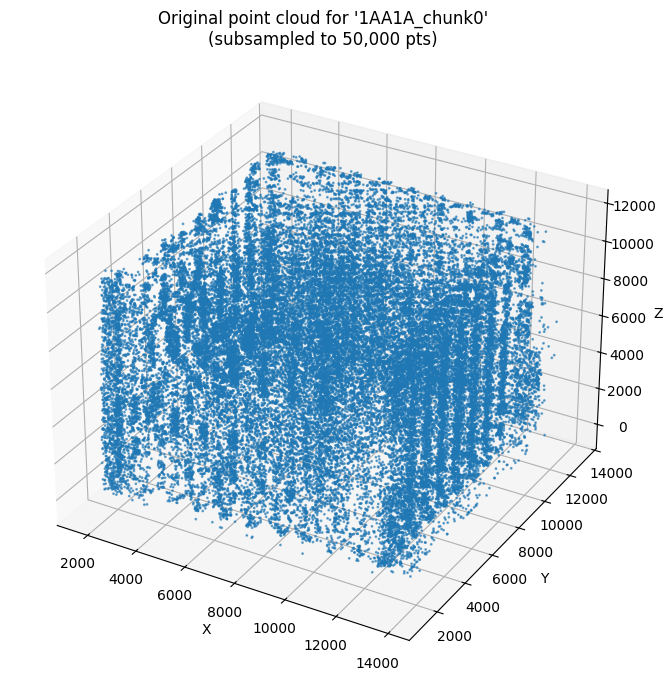

Saved chunked plot to: D:\arashid\cubes\cubes_4\publish\h5\3_1AA1A_chunk0_chunks.png


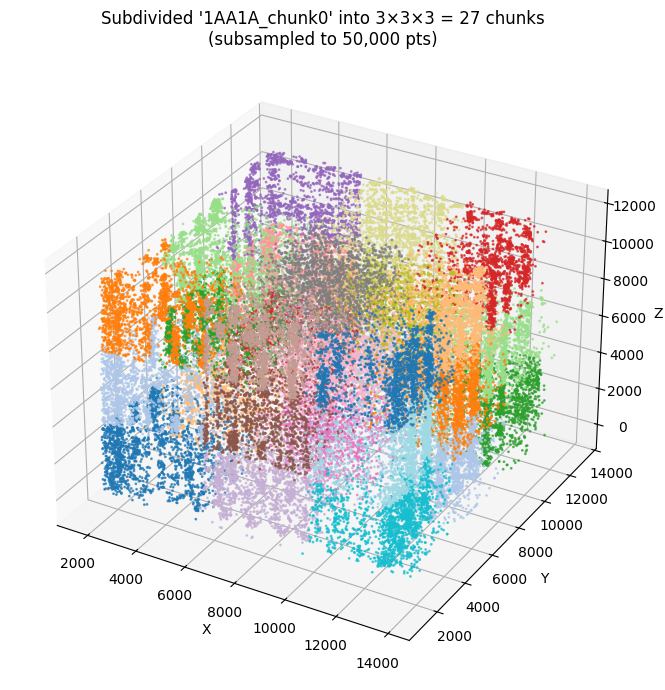

In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt


# User-configurable parameters
# Add the directory and filenames for the input and output h5 files

INPUT_H5   = r"D:\arashid\cubes\cubes_4\publish\h5\cubes_pc_pla_reduced.h5"
OUTPUT_H5  = r"D:\arashid\cubes\cubes_4\publish\h5\cubes_pc_pla_reduced_sectioned_shaved.h5"

# Shave (crop) XY plane by this fraction of the XY extents (total).
# Example: 0.05 => shave 5% total (2.5% from each side in X and Y).
XY_SHAVE_FRAC = 0.05

OUTPUT_DIR = os.path.dirname(OUTPUT_H5)

# Number of divisions along each axis (NX, NY, NZ)
DIVS_X, DIVS_Y, DIVS_Z = 3, 3, 3   # e.g. (2,2,2) → 8 chunks

# Visualization options
SAVE_VIS      = True     # Set False to skip plotting
MAX_PTS_VIS   = 50000    # Maximum number of points to use in each plot (for speed/memory)

# If None, the first dataset will be used for visualization.
# Or set this to a specific dataset name to visualize that one.
VIS_DATASET_NAME = None


# Helper: set equal aspect ratio for 3D axes

def set_axes_equal(ax):
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = x_limits[1] - x_limits[0]
    y_range = y_limits[1] - y_limits[0]
    z_range = z_limits[1] - z_limits[0]
    max_range = max(x_range, y_range, z_range)

    x_middle = np.mean(x_limits)
    y_middle = np.mean(y_limits)
    z_middle = np.mean(z_limits)

    ax.set_xlim3d([x_middle - max_range / 2, x_middle + max_range / 2])
    ax.set_ylim3d([y_middle - max_range / 2, y_middle + max_range / 2])
    ax.set_zlim3d([z_middle - max_range / 2, z_middle + max_range / 2])


# Process all datasets

with h5py.File(INPUT_H5, "r") as fin, h5py.File(OUTPUT_H5, "w") as fout:
    keys = list(fin.keys())
    print(f"Found {len(keys)} datasets in input file.")

    if VIS_DATASET_NAME is not None:
        if VIS_DATASET_NAME not in keys:
            raise KeyError(
                f"VIS_DATASET_NAME '{VIS_DATASET_NAME}' not found. "
                f"Available keys: {keys}"
            )
        vis_key = VIS_DATASET_NAME
    else:
        vis_key = keys[0] 

    print(f"Dataset used for visualization: '{vis_key}'")

    vis_pts = None
    vis_chunk_id = None

    grand_total_written = 0
    grand_empty_cells = 0

    if not (0.0 <= XY_SHAVE_FRAC < 1.0):
        raise ValueError("XY_SHAVE_FRAC must be in [0, 1).")

    for in_key in keys:
        pts = np.array(fin[in_key], dtype=np.float32)
        print(f"\nProcessing dataset '{in_key}' with {pts.shape[0]:,} points")

        # Compute initial bounding box

        xs, ys, zs = pts[:, 0], pts[:, 1], pts[:, 2]

        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()
        z_min, z_max = zs.min(), zs.max()


        # Shave XY plane by a tunable percentage (crop before division)

        if XY_SHAVE_FRAC > 0.0:
            shave_x = (x_max - x_min) * XY_SHAVE_FRAC * 0.5
            shave_y = (y_max - y_min) * XY_SHAVE_FRAC * 0.5

            x_min_shaved = x_min + shave_x
            x_max_shaved = x_max - shave_x
            y_min_shaved = y_min + shave_y
            y_max_shaved = y_max - shave_y

            # Filter points outside shaved region
            mask_xy = (
                (xs >= x_min_shaved) & (xs <= x_max_shaved) &
                (ys >= y_min_shaved) & (ys <= y_max_shaved)
            )

            pts = pts[mask_xy]
            if pts.shape[0] == 0:
                raise ValueError(
                    f"All points removed after XY shaving for dataset '{in_key}'."
                )

            xs, ys, zs = pts[:, 0], pts[:, 1], pts[:, 2]

            # Recompute bounding box AFTER shaving/filtering 
            x_min, x_max = xs.min(), xs.max()
            y_min, y_max = ys.min(), ys.max()
            z_min, z_max = zs.min(), zs.max()

            print(
                f"  Shaved XY by {XY_SHAVE_FRAC*100:.1f}% → "
                f"remaining points: {pts.shape[0]:,}"
            )


        # Compute bin sizes for this dataset

        dx = (x_max - x_min) / DIVS_X
        dy = (y_max - y_min) / DIVS_Y
        dz = (z_max - z_min) / DIVS_Z

        if dx == 0 or dy == 0 or dz == 0:
            raise ValueError(
                f"Zero extent in at least one axis for dataset '{in_key}'; cannot subdivide."
            )

        print("  Bounding box:")
        print(f"    X: [{x_min:.3f}, {x_max:.3f}]  (dx = {dx:.3f})")
        print(f"    Y: [{y_min:.3f}, {y_max:.3f}]  (dy = {dy:.3f})")
        print(f"    Z: [{z_min:.3f}, {z_max:.3f}]  (dz = {dz:.3f})")


        # Assign each point to a (ix, iy, iz) cell

        ix = np.floor((xs - x_min) / dx).astype(int)
        iy = np.floor((ys - y_min) / dy).astype(int)
        iz = np.floor((zs - z_min) / dz).astype(int)

        # Handle max-edge inclusion
        ix = np.clip(ix, 0, DIVS_X - 1)
        iy = np.clip(iy, 0, DIVS_Y - 1)
        iz = np.clip(iz, 0, DIVS_Z - 1)


        chunk_id = ix * (DIVS_Y * DIVS_Z) + iy * DIVS_Z + iz


        # Prepare output chunk naming

        if "_chunk" in in_key:
            base_name = in_key.split("_chunk")[0]
        else:
            base_name = in_key  # fallback

        print(f"  Base name for output chunks: '{base_name}'")

        total_written = 0
        empty_cells = 0

        for ix_idx in range(DIVS_X):
            for iy_idx in range(DIVS_Y):
                for iz_idx in range(DIVS_Z):
                    mask = (ix == ix_idx) & (iy == iy_idx) & (iz == iz_idx)
                    cell_pts = pts[mask]

                    if cell_pts.shape[0] == 0:
                        empty_cells += 1
                        continue

                    ds_name = f"{base_name}_x{ix_idx+1}y{iy_idx+1}z{iz_idx+1}"
                    fout.create_dataset(ds_name, data=cell_pts.astype(np.float32))

                    total_written += cell_pts.shape[0]
                    print(f"    {ds_name}: {cell_pts.shape[0]:,} points")

        print(f"  Total points written for '{in_key}': {total_written:,}")
        print(f"  Empty cells for '{in_key}': {empty_cells}")

        grand_total_written += total_written
        grand_empty_cells += empty_cells

        # Store for visualization if this is the chosen dataset
        if SAVE_VIS and in_key == vis_key:
            vis_pts = pts
            vis_chunk_id = chunk_id

print(f"\n======= Summary over all datasets =======")
print(f"Grand total points written: {grand_total_written:,}")
print(f"Total empty cells across all datasets: {grand_empty_cells}")
print(f"Saved subdivided HDF5 to:\n{OUTPUT_H5}")


# Visualization: original and chunked view for one dataset

if SAVE_VIS and vis_pts is not None:
    xs = vis_pts[:, 0]
    ys = vis_pts[:, 1]
    zs = vis_pts[:, 2]
    chunk_id = vis_chunk_id

    n_pts = vis_pts.shape[0]
    if n_pts > MAX_PTS_VIS:
        idx_vis = np.random.choice(n_pts, size=MAX_PTS_VIS, replace=False)
    else:
        idx_vis = np.arange(n_pts)

    xs_vis = xs[idx_vis]
    ys_vis = ys[idx_vis]
    zs_vis = zs[idx_vis]
    chunk_id_vis = chunk_id[idx_vis]

    # 1) Original cloud (single color)
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(xs_vis, ys_vis, zs_vis, s=1, alpha=0.6)

    ax.set_title(
        f"Original point cloud for '{vis_key}'\n"
        f"(subsampled to {len(idx_vis):,} pts)"
    )
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    set_axes_equal(ax)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"3_{vis_key}_original.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved original plot to: {save_path}")
    plt.show()

    # 2) Chunked cloud (color-coded by chunk)
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")

    cmap = plt.get_cmap("tab20")
    num_chunks = DIVS_X * DIVS_Y * DIVS_Z

    colors = cmap(chunk_id_vis % cmap.N)
    ax.scatter(xs_vis, ys_vis, zs_vis, s=1, c=colors, alpha=0.7)

    ax.set_title(
        f"Subdivided '{vis_key}' into {DIVS_X}×{DIVS_Y}×{DIVS_Z} = {num_chunks} chunks\n"
        f"(subsampled to {len(idx_vis):,} pts)"
    )
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    set_axes_equal(ax)
    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"3_{vis_key}_chunks.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved chunked plot to: {save_path}")
    plt.show()
